# Feature engineering

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold

from heart_failure.config.config import (
    INTERIM_DATA_DIR,
    PROCESSED_DATA_DIR,
    HEART_DISEASE,
    SEX,
    EXERCISE_ANGINA,
    FASTING_BS,
    RESTING_ECG
)
from heart_failure.dataset import split_data
from heart_failure.config.features import RANDOM_STATE, TE_CV
from heart_failure.features import get_fe_pipeline
from heart_failure.feature_selection import select_by_vif, find_best_corr_threshold
from heart_failure.plots import plot_corr_matrix, kdeplot_features_by_target

In [2]:
df = pd.read_csv(INTERIM_DATA_DIR / "heart.csv")

y = df[HEART_DISEASE]
X = df.drop(columns=[HEART_DISEASE])

X_train, y_train, X_val, y_val, X_test, y_test = split_data(
    X, y, stratify_func=lambda X, y: pd.concat([X[[SEX]], y], axis=1)
)

### Feature implementing

In [3]:
cv = StratifiedKFold(n_splits=TE_CV, shuffle=True, random_state=RANDOM_STATE)
fe_pipeline = get_fe_pipeline(cv, n_bins=8)

In [4]:
X_train = fe_pipeline.fit_transform(X_train, y_train)
X_test = fe_pipeline.transform(X_test)

In [5]:
X_train.head()

,target_encoder__RestingECG,target_encoder__ChestPainType,target_encoder__ST_Slope,binner__Age,binner__Cholesterol,binner__MaxHR,binary_encoder__Sex,binary_encoder__FastingBS,binary_encoder__ExerciseAngina,remainder__RestingBP,...,remainder__Age_MaxHR_ratio,remainder__Oldpeak_ChestPainType_te,remainder__Oldpeak_Cholesterol_ST_Slope_te,remainder__MaxHR_RestingECG_te,remainder__Age_Cholesterol_Sex_te,remainder__ChestPainType_Sex_te,remainder__ST_Slope_Sex_te,remainder__FastingBS_ST_Slope_te,remainder__FastingBS_ChestPainType_te,remainder__FastingBS_ExerciseAngina_te
839,0.518974,0.158438,0.847055,0.0,1.0,3.0,1.0,0.0,0.0,135.0,...,0.310606,0.081867,0.792238,0.618826,0.426938,0.206661,0.900820,0.805747,0.121224,0.250968
351,0.638348,0.782036,0.182399,1.0,4.0,4.0,1.0,0.0,1.0,140.0,...,0.307143,0.833492,0.580986,0.542095,0.642177,0.828384,0.229814,0.130530,0.698837,0.834543
398,0.526223,0.805471,0.193831,3.0,3.0,2.0,1.0,1.0,1.0,165.0,...,0.426230,0.843779,0.596987,0.599322,0.833842,0.837741,0.257855,0.415644,0.958592,0.921032
563,0.626761,0.790451,0.845560,5.0,6.0,6.0,1.0,1.0,1.0,144.0,...,0.356250,0.933698,0.912481,0.267969,0.781371,0.829748,0.894383,0.974480,0.937159,0.926778
190,0.626761,0.790451,0.172154,1.0,6.0,2.0,1.0,0.0,0.0,180.0,...,0.383333,0.584768,0.112236,0.663341,1.000000,0.829748,0.235258,0.139357,0.726525,0.245693


In [6]:
X_train.isna().sum().sort_values(ascending=False).head()

target_encoder__RestingECG       0
target_encoder__ChestPainType    0
target_encoder__ST_Slope         0
binner__Age                      0
binner__Cholesterol              0
dtype: int64

In [7]:
X_test.isna().sum().sort_values(ascending=False).head()

target_encoder__RestingECG       0
target_encoder__ChestPainType    0
target_encoder__ST_Slope         0
binner__Age                      0
binner__Cholesterol              0
dtype: int64

### Feature correlation

In [8]:
train = X_train.merge(y_train, left_index=True, right_index=True)
corr_df = train.corr()

In [9]:
plot_corr_matrix(corr_df, width=800, height=800, fontsize=9)

Multicollinearity is present. When we calculate gender target encoding (ex.) into bins of some other feature, the probability of class 1 appearing can be repeated across splits by different features. Therefore, they are highly correlated with each other.

The features ChestPainType (te) and FastingBS_ChestPainType (te); ST_Slope (te) and FastingBS_ST_Slope are also highly correlated. This is explained by the fact that FastingBS is not a significant indicator of the disease, but simply represents the age group most susceptible to the disease.

In [10]:
thresholds = [0.02, 0.05, 0.1, 0.15]

best_threshold, thr_result = find_best_corr_threshold(X_train, y_train, thresholds)
thr_result

,threshold,features,score_mean,score_std
2,0.10,20,0.798633,0.063036
1,0.05,21,0.797513,0.065339
0,0.02,22,0.795207,0.065455
3,0.15,19,0.793266,0.075551


In [11]:
low_correlated = corr_df[corr_df[HEART_DISEASE].abs() < best_threshold].index.to_list()
low_correlated

['target_encoder__RestingECG', 'remainder__RestingBP']

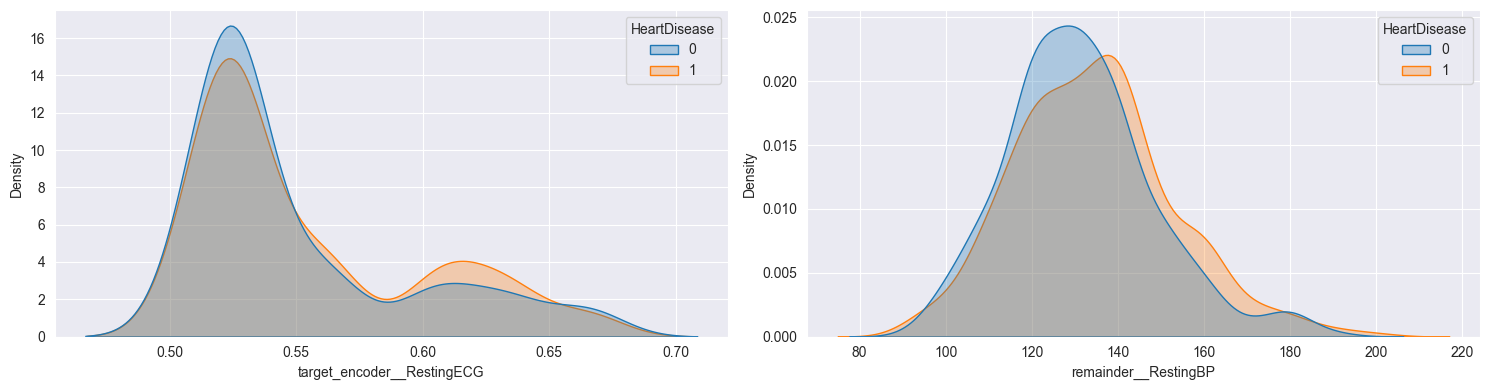

In [12]:
kdeplot_features_by_target(train, low_correlated, HEART_DISEASE)

For RestingECG, the correlation was expected to be small (the percentages initially didn't vary much across categories).

In [13]:
X_train = X_train.drop(columns=low_correlated)
X_test = X_test.drop(columns=low_correlated)

In [14]:
remaining_cols, drop_order = select_by_vif(X_train, y_train)
drop_order

target_encoder__ChestPainType             1093.882221
target_encoder__ST_Slope                   436.795974
remainder__FastingBS_ChestPainType_te      253.319084
remainder__FastingBS_ST_Slope_te           121.195470
remainder__FastingBS_ExerciseAngina_te      74.410571
remainder__Age_MaxHR_ratio                  57.594179
remainder__Oldpeak_ChestPainType_te         40.132464
remainder__ST_Slope_Sex_te                  25.933741
remainder__Age_Cholesterol_Sex_te           13.434515
dtype: float64

In [15]:
remaining_cols

['binner__Age',
 'binner__Cholesterol',
 'binner__MaxHR',
 'binary_encoder__Sex',
 'binary_encoder__FastingBS',
 'binary_encoder__ExerciseAngina',
 'remainder__Oldpeak',
 'remainder__conjunctive_rules',
 'remainder__Oldpeak_Cholesterol_ST_Slope_te',
 'remainder__MaxHR_RestingECG_te',
 'remainder__ChestPainType_Sex_te']

In [16]:
train = X_train[remaining_cols].merge(y_train, left_index=True, right_index=True)
corr_df = train.corr()
plot_corr_matrix(corr_df, width=600, height=600, fontsize=9)

In [17]:
pd.Series(remaining_cols).to_csv(PROCESSED_DATA_DIR / 'remaining_cols.csv', index=False)

### Binned features

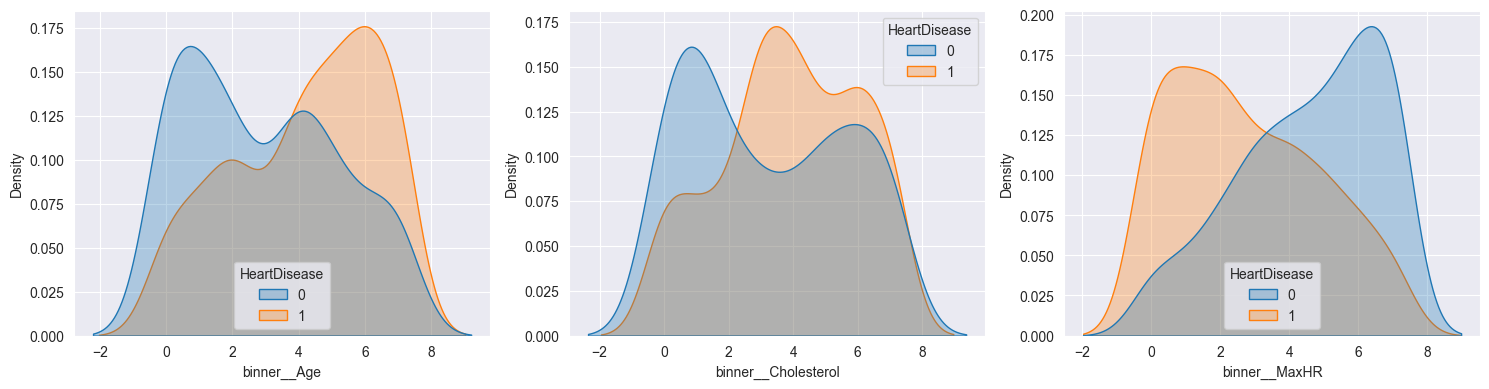

In [18]:
binned = X_train.columns[X_train.columns.str.startswith("binner__")]
kdeplot_features_by_target(train, binned, HEART_DISEASE)

Target correlation with binned features has increased. Class distributions do not overlap. Binning definitely helps for cholesterol, which has abnormally high values. Age and MaxHR also have rare high/low values. This helps at least linear models.

In [19]:
X_train_raw = df.loc[X_train.index]

Age: False
Cholesterol: False
MaxHR: False


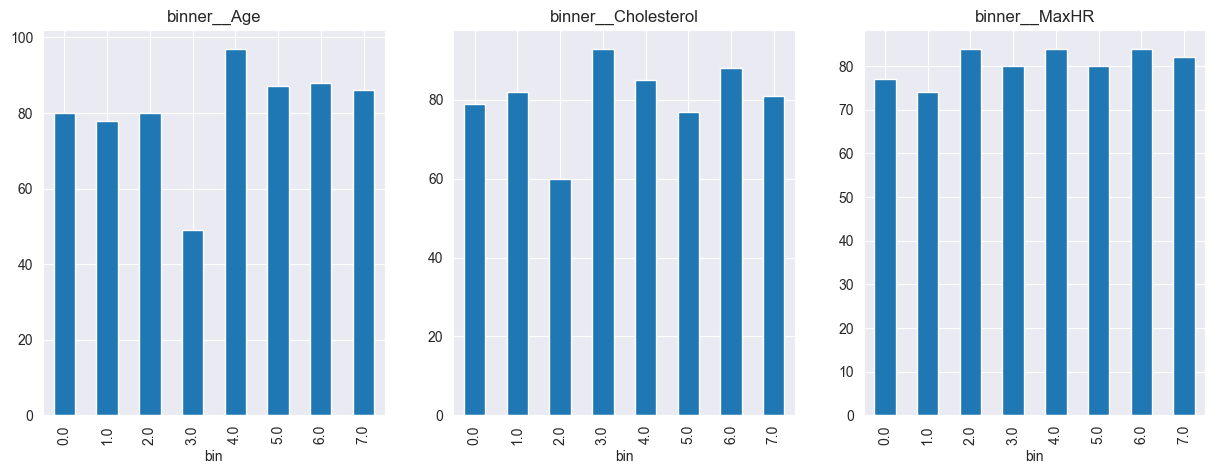

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for col, ax in zip(binned, axes):
    raw_cal = col.removeprefix("binner__")
    tmp = pd.DataFrame({raw_cal: X_train_raw[raw_cal], "bin": X_train[col]})
    tmp["bin"].value_counts().sort_index().plot(kind="bar", ax=ax)
    ax.set_title(col)
    unique = tmp.groupby(raw_cal)["bin"].nunique().sort_values(ascending=False)
    print(f"{raw_cal}:", unique.iloc[0] > 1)

In [21]:
binner = fe_pipeline.named_steps["preprocessor"].named_transformers_["binner"]
edges = pd.Series(binner.bin_edges_)
edges.index = binned
edges

binner__Age            [28.0, 42.0, 48.0, 52.0, 54.0, 57.0, 60.0, 64....
binner__Cholesterol    [85.0, 194.0, 216.0, 228.0, 237.0, 248.0, 269....
binner__MaxHR          [60.0, 106.0, 120.0, 128.0, 138.0, 146.0, 155....
dtype: object

The bin situation is more or less normal. Of course, there are some bins that are rare, but not that much. With 10 bins, the situation was worse, as there were several bins with relatively few values.

### Conjunctive rules - unaccounted diseases

In [27]:
df_train = df.loc[X_train.index]
df_train[(X_train["remainder__conjunctive_rules"] == 0) & (y_train == 1)]

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
866,44,M,ASY,112.0,290.0,0,LVH,153,N,0.0,Up,1
616,57,M,ATA,124.0,261.0,0,Normal,141,N,0.3,Up,1
661,44,M,ASY,110.0,197.0,0,LVH,177,N,0.0,Up,1
119,34,M,TA,140.0,156.0,0,Normal,180,N,0.0,Flat,1
660,49,M,NAP,118.0,149.0,0,LVH,126,N,0.8,Up,1
354,55,M,ASY,120.0,228.0,0,ST,92,N,0.3,Up,1
683,47,M,NAP,108.0,243.0,0,Normal,152,N,0.0,Up,1
708,52,M,ASY,125.0,212.0,0,Normal,168,N,1.0,Up,1
513,43,M,ASY,122.0,237.0,0,Normal,120,N,0.5,Up,1
375,73,F,NAP,160.0,269.0,0,ST,121,N,0.0,Up,1


1. Age, RestingBP, Cholesterol, and MaxHR vary from low to high, with no dominant group.
2. CPT: NAP is slightly more common than usually.
3. FastingBS is predominantly 0.
4. RestingECG: LVH as common as Normal.
5. ExerciseAngina is predominantly N.
6. Oldpeak is mostly 0, the rest are less than or equal to 1.
7. ST_Slope is predominantly Up.

- Points usually indicating the absence of disease: 5, 6, 7.
- Points indicating the presence of disease 50/50: 2 (due to a mixture of "strong" ASY and "weak" NAP), 3, 4.

Let's select ExerciseAngina=N, FastingBS=0, RestingECG=LVH. What percentage of diseases are in a train with this combination?

In [43]:
mask = (df_train[EXERCISE_ANGINA] == "N") & (df_train[RESTING_ECG] == "LVH") & (df_train[FASTING_BS] == 0)
y_train[mask].agg(["mean", "count"])

mean      0.366667
count    60.000000
Name: HeartDisease, dtype: float64

The percentage is small. It is unlikely that there are unaccounted disease dependencies outside the conjunctive_rules.